In [25]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

In [26]:
from typing_extensions import Annotated,TypedDict
from langgraph.graph import add_messages
from langgraph.graph import MessagesState

class State(MessagesState):
    #messages: Annotated[list, add_messages]
    summary: str

In [27]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    # Get summary if it exists
    summary = state.get("summary", "")
    
    # If there is summary, then we add it
    if summary:
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"
        
        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = llm.invoke(messages)
    return {"messages": [response]}

In [28]:



def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get("summary", "")
    
    # Create our summarization prompt
    if summary:
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    
    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)

    messages_tobe_removed = [RemoveMessage(id=msg.id) for msg in state["messages"][:-2]]

    return {"summary": response.content , "messages": messages_tobe_removed}

In [29]:
def where_to_go(state: State) ->str:
    if len(state["messages"]) > 6:
        return "summarize"
    else:
        return "end"


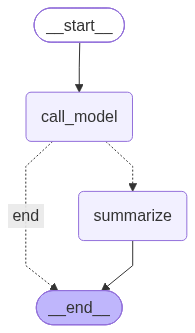

In [30]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

workflow = StateGraph(State)
workflow.add_node("summarize", summarize_conversation)
workflow.add_node("call_model", call_model)
workflow.add_conditional_edges("call_model", where_to_go, {"summarize": "summarize", "end": END})
workflow.add_edge(START, "call_model")
workflow.add_edge("summarize", END)

summarization_graph=workflow.compile(checkpointer=checkpointer)
summarization_graph

In [31]:
config = {"configurable": {"thread_id": "1"}}
result = summarization_graph.invoke({
    "messages": [HumanMessage(content="I am Siva Prasad")]
}, config   )
result

{'messages': [HumanMessage(content='I am Siva Prasad', additional_kwargs={}, response_metadata={}, id='15f64a43-4e7b-404a-b611-da1152f5c37c'),
  AIMessage(content='Hello, Siva Prasad! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 13, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1bcbffccf6', 'id': 'chatcmpl-EU4VXd8kkEuHK04SLORJvWy2oHhRx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f622-d8e3-71d3-9298-172c054ea08c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [32]:
config = {"configurable": {"thread_id": "1"}}
result = summarization_graph.invoke({
    "messages": [HumanMessage(content="I love python")]
}, config   )
result

{'messages': [HumanMessage(content='I am Siva Prasad', additional_kwargs={}, response_metadata={}, id='15f64a43-4e7b-404a-b611-da1152f5c37c'),
  AIMessage(content='Hello, Siva Prasad! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 13, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1bcbffccf6', 'id': 'chatcmpl-EU4VXd8kkEuHK04SLORJvWy2oHhRx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f622-d8e3-71d3-9298-172c054ea08c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [33]:
config = {"configurable": {"thread_id": "1"}}
result = summarization_graph.invoke({
    "messages": [HumanMessage(content="I love langgraph")]
}, config   )
result

{'messages': [HumanMessage(content='I am Siva Prasad', additional_kwargs={}, response_metadata={}, id='15f64a43-4e7b-404a-b611-da1152f5c37c'),
  AIMessage(content='Hello, Siva Prasad! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 13, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1bcbffccf6', 'id': 'chatcmpl-EU4VXd8kkEuHK04SLORJvWy2oHhRx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f622-d8e3-71d3-9298-172c054ea08c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [34]:
config = {"configurable": {"thread_id": "1"}}
result = summarization_graph.invoke({
    "messages": [HumanMessage(content="I love java")]
}, config   )
result

{'messages': [HumanMessage(content='I love java', additional_kwargs={}, response_metadata={}, id='0d5e01be-d468-4093-a7ee-071d50b8a6ba'),
  AIMessage(content="That's awesome! Java is a widely-used programming language known for its portability, performance, and strong object-oriented principles. Many developers appreciate its versatility in building web applications, mobile apps (especially for Android), and large-scale enterprise systems.\n\nWhat do you enjoy most about Java? Are you working on any projects or learning particular concepts in Java?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 156, 'total_tokens': 223, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'mode

In [35]:
from IPython.display import Markdown

Markdown(result['summary'])

In the conversation, Siva Prasad expressed his love for both Python and Java. He mentioned his enthusiasm for Python, a versatile programming language, and also stated his appreciation for LangGraph, a tool that combines natural language processing with graph-based representations. The conversation included questions about specific interests and projects related to these languages. Overall, it highlighted Siva Prasad's enthusiasm for programming and the tools he enjoys using.

In [36]:
def where_to_go_agent(state: State) ->str:

    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"


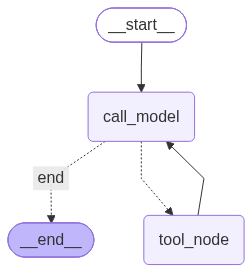

In [37]:
from tkinter import W
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch

agent_workflow = StateGraph(State)
agent_workflow.add_node("call_model", summarization_graph)
agent_workflow.add_node("tool_node", ToolNode([TavilySearch()]))
agent_workflow.add_edge(START, "call_model")
agent_workflow.add_conditional_edges("call_model", where_to_go_agent, {"tool_node": "tool_node", "end": END})
agent_workflow.add_edge("tool_node", "call_model")

agent =agent_workflow.compile(checkpointer=checkpointer)
agent


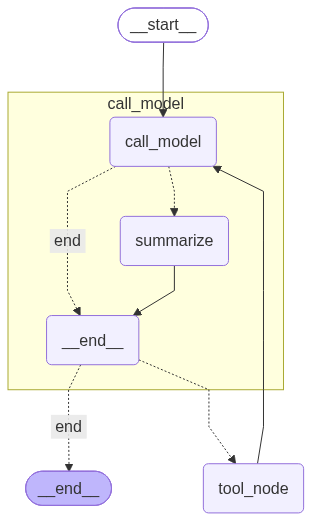

In [40]:
from IPython.display import Image

Image(agent.get_graph(xray=1).draw_mermaid_png())